In [3]:
import os
import glob
import pandas as pd
import numpy as np
import xarray as xr
from xmip.preprocessing import rename_cmip6
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import json
import cftime
import matplotlib
import warnings
import matplotlib.pyplot as plt
from Utils import get_ds_from_ceda
from Utils import weighted_annual_resample
import seaborn as sns
warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'font.size': 15})

from HiLLA_utils import get_ds, cut_incomplete_years, spatial_mean, set_time_to_center_of_bounds

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, colours, model_colors

In [4]:
def get_AOD(run):
    variables = ['od_aer_0', 'od_aer_1', 'od_aer_2', 'od_aer_3', 'od_aer_dust']
    ds_list = []
    for variable in variables:
        ds = get_ds(run=run, var=variable, table='AERmon', zonal_mean=False)
        ds = ds.sel(coordinate=3) # select 550nm
        ds_list.append(ds)
    total_AOD = ds_list[0]['od_aer_0'] + ds_list[1]['od_aer_1'] + ds_list[2]['od_aer_2'] + ds_list[3]['od_aer_3'] + ds_list[4]['od_aer_dust']
    return total_AOD.to_dataset(name='AOD550')

def get_hemispheric_means(aod):
    aod_NH = aod.sel(latitude=slice(0, 91))
    aod_SH = aod.sel(latitude=slice(-91, 0))
    weights = np.cos(np.deg2rad(aod_NH['latitude']))
    aod_NH_ts = aod_NH.weighted(weights).mean(dim='latitude')
    weights = np.cos(np.deg2rad(aod_SH['latitude']))
    aod_SH_ts = aod_SH.weighted(weights).mean(dim='latitude')
    return aod_NH_ts.mean('time').AOD550.values.item(), aod_SH_ts.mean('time').AOD550.values.item()

In [13]:
### UKESM

### get background first
background_dir = '/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/od550aer/gn/latest/'
AOD_background_ds_UK = xr.open_mfdataset(background_dir + '*.nc').sel(time=slice('2035', '2069')).rename({'lat':'latitude', 'lon':'longitude'})

### get HiLLA
aod_HiLLA_13_UK = get_AOD('u-dm204dn587')
aod_HiLLA_15_UK = get_AOD('u-dn760')

### switch to anomaly from r1
AOD_anom_HiLLA_13_UK = (aod_HiLLA_13_UK['AOD550'] - AOD_background_ds_UK['od550aer']).to_dataset(name='AOD550_delta')
AOD_anom_HiLLA_15_UK = (aod_HiLLA_15_UK['AOD550'] - AOD_background_ds_UK['od550aer']).to_dataset(name='AOD550_delta')


### CESM
CESM_AOD_var = 'AODVIS'
CESM_AOD_table = 'AOD550_FullAtmos'

### NB - it doesn't make much difference changing between AODVIS and AODVISdn, since we have little aod in polar winter anyway


### get background first
background_dir = '/badc/cmip6/data/CMIP6/ScenarioMIP/NCAR/CESM2-WACCM/ssp245/r1i1p1f1/AERmon/od550aer/gn/latest/'
AOD_background_ds_CE = xr.open_mfdataset(background_dir + '*.nc').sel(time=slice('2035', '2069')).rename({'lat':'latitude', 'lon':'longitude'})

### get HiLLA
aod_HiLLA_13_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/{t}/case01_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_13km_MAMJ_6Tg.001.cam.h0.{v}.203501-206912.nc'.format(t=CESM_AOD_table, v=CESM_AOD_var)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069')).load()
aod_HiLLA_15_CE = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'CESM_data/{t}/case04_b.e21.BWSSP245cmip6.f09_g17.polar_SAI_sensitivity_60NS_15km_MAMJ_6Tg.001.cam.h0.{v}.203501-206912.nc'.format(t=CESM_AOD_table, v=CESM_AOD_var)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069')).load()


### switch to anomaly from r1
AOD_anom_HiLLA_13_CE = (aod_HiLLA_13_CE[CESM_AOD_var].resample(time="1MS").mean() - AOD_background_ds_CE['od550aer'].resample(time="1MS").mean()).to_dataset(name='AOD550_delta')
AOD_anom_HiLLA_15_CE = (aod_HiLLA_15_CE[CESM_AOD_var].resample(time="1MS").mean()  - AOD_background_ds_CE['od550aer'].resample(time="1MS").mean() ).to_dataset(name='AOD550_delta')


### E3SM
E3SM_AOD_table = 'regridded/AODVIS'

### get background first
AOD_background_ds_E3 = cut_incomplete_years(xr.open_mfdataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.control.nc'.format(t=E3SM_AOD_table)).sel(time=slice('2035', '2069')).rename({'lat':'latitude', 'lon':'longitude'}))

### get HiLLA
aod_HiLLA_13_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.01.nc'.format(t=E3SM_AOD_table)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069'))
aod_HiLLA_15_E3 = set_time_to_center_of_bounds(xr.open_dataset(path_archive+'E3SM_data/{t}/AODVIS.polar.mip.e3sm.04.nc'.format(t=E3SM_AOD_table)), 'time_bnds').rename({'lat':'latitude', 'lon':'longitude'}).sel(time=slice(None, '2069'))


### switch to anomaly from r1
AOD_anom_HiLLA_13_E3 = (aod_HiLLA_13_E3[CESM_AOD_var].resample(time="1MS").mean() - AOD_background_ds_E3[CESM_AOD_var].resample(time="1MS").mean()).to_dataset(name='AOD550_delta')
AOD_anom_HiLLA_15_E3 = (aod_HiLLA_15_E3[CESM_AOD_var].resample(time="1MS").mean()  - AOD_background_ds_E3[CESM_AOD_var].resample(time="1MS").mean() ).to_dataset(name='AOD550_delta')


In [14]:
### combine aods into a dict

## combine into a dict
HiLLA_aod_data = {'UKESM':{'13km':AOD_anom_HiLLA_13_UK, '15km':AOD_anom_HiLLA_15_UK},
                  'CESM':{'13km':AOD_anom_HiLLA_13_CE, '15km':AOD_anom_HiLLA_15_CE},
                  'E3SM':{'13km':AOD_anom_HiLLA_13_E3, '15km':AOD_anom_HiLLA_15_E3}}

## reduce HiLLA data to annually resampled timeseries
timeseries_dicts_models = []
for model in models:
    timeseries_dicts = []
    for alt in HiLLA_altitudes:
        print(model, alt)
        data = HiLLA_aod_data[model][alt]
        timeseries_dicts.append(dict(zip(regions, [spatial_mean(data, region, var='AOD550_delta') for region in regions])))
    
    timeseries_dicts_models.append(dict(zip(HiLLA_altitudes, timeseries_dicts)))

HiLLA_aod_timeseries_dict = dict(zip(models, timeseries_dicts_models))

UKESM 13km
UKESM 15km
CESM 13km
CESM 15km
E3SM 13km
E3SM 15km


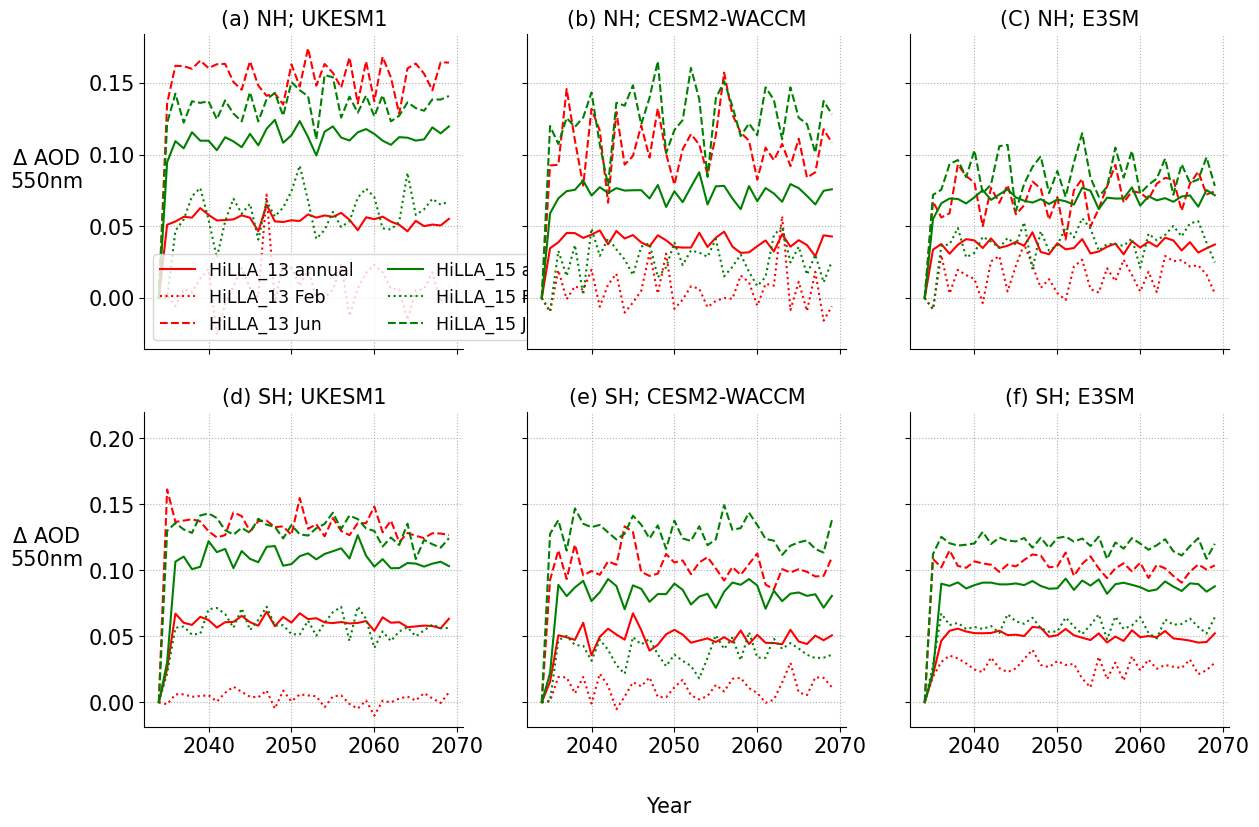

In [15]:
## now plot AOD timeseries

fig, axs = plt.subplots(2, 3, figsize=(14, 9), sharey='row', sharex=True)

run_labels = ['HiLLA_13', 'HiLLA_15']

# NH
ax = axs[0, 0]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_UK, AOD_anom_HiLLA_15_UK]:
    AOD_anom = AOD_anom.sel(latitude=slice(0, 91))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_feb = AOD_ts.where(AOD_ts.time.dt.month==2, drop=True)
    AOD_ts_jun = AOD_ts.where(AOD_ts.time.dt.month==6, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} Feb'.format(run_labels[i]), '{} Jun'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_feb, AOD_ts_jun]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize='small', ncols=2)
ax.grid(ls='dotted')

ax = axs[0, 1]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_CE, AOD_anom_HiLLA_15_CE]:
    AOD_anom = AOD_anom.sel(latitude=slice(0, 91))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_feb = AOD_ts.where(AOD_ts.time.dt.month==2, drop=True)
    AOD_ts_jun = AOD_ts.where(AOD_ts.time.dt.month==6, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} Feb'.format(run_labels[i]), '{} Jun'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_feb, AOD_ts_jun]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.legend(fontsize='small', ncols=2)
ax.grid(ls='dotted')


ax = axs[0, 2]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_E3, AOD_anom_HiLLA_15_E3]:
    AOD_anom = AOD_anom.sel(latitude=slice(0, 91))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_feb = AOD_ts.where(AOD_ts.time.dt.month==2, drop=True)
    AOD_ts_jun = AOD_ts.where(AOD_ts.time.dt.month==6, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} Feb'.format(run_labels[i]), '{} Jun'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_feb, AOD_ts_jun]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.legend(fontsize='small', ncols=2)
ax.grid(ls='dotted')


# SH
ax = axs[1, 0]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_UK, AOD_anom_HiLLA_15_UK]:
    AOD_anom = AOD_anom.sel(latitude=slice(-91, 0))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_aug = AOD_ts.where(AOD_ts.time.dt.month==8, drop=True)
    AOD_ts_dec = AOD_ts.where(AOD_ts.time.dt.month==12, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} August'.format(run_labels[i]), '{} December'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_aug, AOD_ts_dec]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
#ax.plot([], [], c='blue', ls='solid', label='Case 1 (60°-13km-MAMJ)')
#ax.axhline(np.mean(aods[-20:]), c='gray', ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.legend(fontsize='small', ncols=2)
ax.set_ylim(None, 0.22)
ax.grid(ls='dotted')

# SH
ax = axs[1, 1]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_CE, AOD_anom_HiLLA_15_CE]:
    AOD_anom = AOD_anom.sel(latitude=slice(-91, 0))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_aug = AOD_ts.where(AOD_ts.time.dt.month==8, drop=True)
    AOD_ts_dec = AOD_ts.where(AOD_ts.time.dt.month==12, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} August'.format(run_labels[i]), '{} December'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_aug, AOD_ts_dec]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
#ax.plot([], [], c='blue', ls='solid', label='Case 1 (60°-13km-MAMJ)')
#ax.axhline(np.mean(aods[-20:]), c='gray', ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#ax.legend(fontsize='small', ncols=2)
ax.set_ylim(None, 0.22)
ax.grid(ls='dotted')


# SH
ax = axs[1, 2]
i=0
for AOD_anom in [AOD_anom_HiLLA_13_E3, AOD_anom_HiLLA_15_E3]:
    AOD_anom = AOD_anom.sel(latitude=slice(-91, 0))
    AOD_zonal = AOD_anom.mean(dim='longitude')
    weights = np.cos(np.deg2rad(AOD_zonal['latitude']))
    AOD_ts = AOD_zonal.weighted(weights).mean(dim='latitude')
    # get june and february:    
    AOD_ts_aug = AOD_ts.where(AOD_ts.time.dt.month==8, drop=True)
    AOD_ts_dec = AOD_ts.where(AOD_ts.time.dt.month==12, drop=True)
    AOD_ts = AOD_ts.resample(time='1YE').mean()
    l=0
    styles_list = ['solid', 'dotted', 'dashed']
    label_list = ['{} annual'.format(run_labels[i]), '{} August'.format(run_labels[i]), '{} December'.format(run_labels[i])]
    for ts in [AOD_ts, AOD_ts_aug, AOD_ts_dec]:
        years = np.concatenate(([2034], [x for x in ts.time.dt.year.values]))
        aods = np.concatenate(([0], [x for x in ts.AOD550_delta.values]))
        ax.plot(years, aods, c=colours[['HiLLA_13', 'HiLLA_15'][i]], ls=styles_list[l], label=label_list[l])
        l=l+1
    i=i+1
#ax.plot([], [], c='blue', ls='solid', label='Case 1 (60°-13km-MAMJ)')
#ax.axhline(np.mean(aods[-20:]), c='gray', ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(ls='dotted')



axs[0, 0].set_title('(a) NH; UKESM1', fontsize='medium')
axs[0, 1].set_title('(b) NH; CESM2-WACCM', fontsize='medium')
axs[0, 2].set_title('(C) NH; E3SM', fontsize='medium')
axs[1, 0].set_title('(d) SH; UKESM1', fontsize='medium')
axs[1, 1].set_title('(e) SH; CESM2-WACCM', fontsize='medium')
axs[1, 2].set_title('(f) SH; E3SM', fontsize='medium')
axs[0, 0].set_ylabel('\u0394 AOD\n550nm', rotation =0, labelpad=30)
axs[1, 0].set_ylabel('\u0394 AOD\n550nm', rotation =0, labelpad=30)
fig.supxlabel('Year', fontsize='medium')

plt.savefig('Figures/AOD_evolution_longersims_v2.jpg', dpi=350)

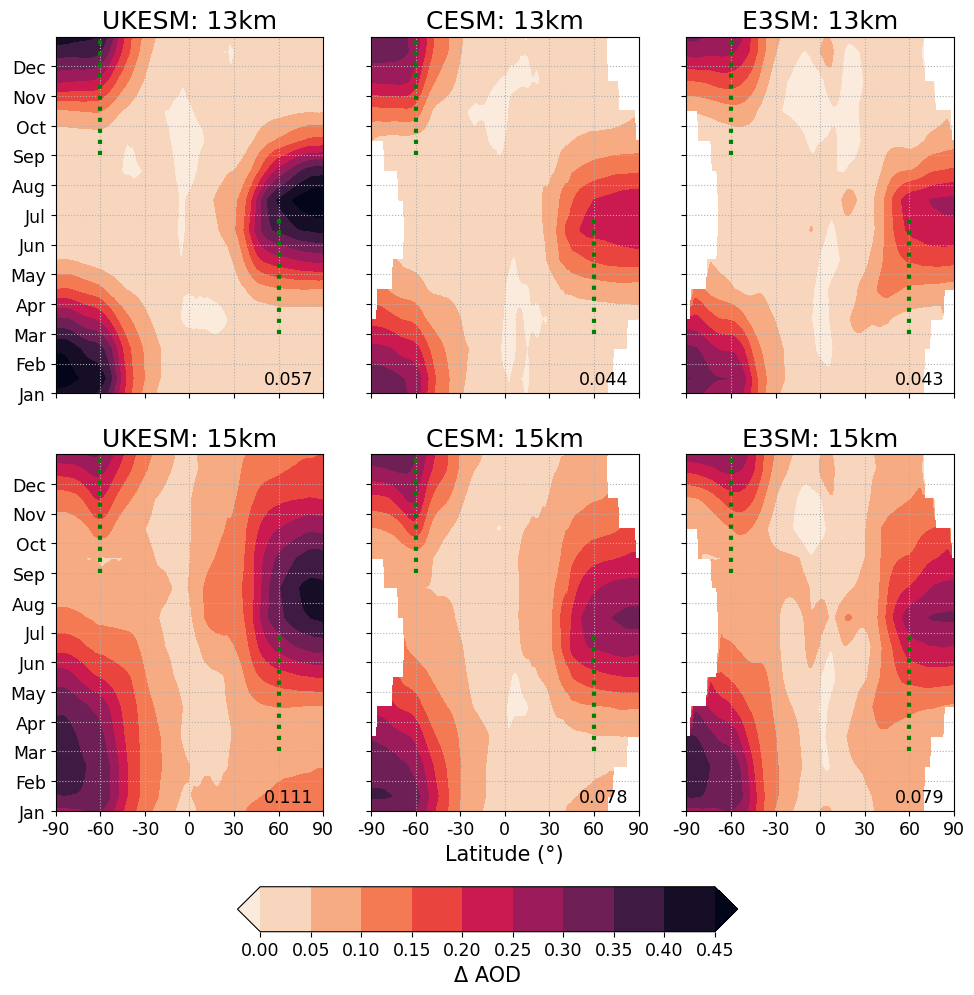

In [16]:
## Hovmoller AOD plots:

fig, axs = plt.subplots(2, 3, figsize=(10, 9),  sharex='all', sharey='all')

i=0
for alt in HiLLA_altitudes:
    for model in models:
        ax = axs.flatten()[i]
        data = HiLLA_aod_data[model][alt].sel(time=slice('2050', '2069')).mean('longitude')
        data = data.groupby(data.time.dt.month).mean()
        ## need to add a cyclic point to loop contouring between dec and jan:
        monthly_data, lats = data.AOD550_delta.values, data.latitude.values
        # Duplicate the first and last month's data and append it to the start and end
        cyclic_monthly_data = np.concatenate((monthly_data[11:12, :], monthly_data, monthly_data[0:1, :]), axis=0)
        # Create corresponding month coordinates for contourf
        cyclic_months = np.arange(-0.5, 13.5, 1)
        
        cs=ax.contourf(lats, cyclic_months,
                       cyclic_monthly_data,
                       levels = np.arange(0, 0.46, 0.05),
                       cmap=sns.color_palette("rocket_r", as_cmap=True),
                       extend='both')

        # also get global mean:
        global_mean = HiLLA_aod_timeseries_dict[model][alt]['Global'].sel(time=slice('2050', '2069'))
        global_mean = weighted_annual_resample(global_mean, 'AOD550_delta').mean('time').AOD550_delta.values.item()
        ax.text(50, 0.3, str(np.round(global_mean, 3)), fontsize='small')
        ax.set_ylim(0,12)
        ax.set_xticks([-90, -60, -30, 0, 30, 60, 90])
        ax.set_xticklabels(['-90', '-60', '-30', '0', '30', '60', '90'], fontsize='small')
        #ax.set_yticks([1, 3, 5, 7, 9, 11])
        ax.set_yticks([0,1,2,3,4,5,6,7,8,9,10,11])
        #ax.set_yticklabels(['Jan', 'Mar', 'May', 'Jul', 'Sep', 'Nov'], fontsize='small')
        ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], fontsize='small')
        #ax.set_yticklabels(['Mar', 'Jun', 'Sep'], fontsize='small')
        ax.grid(ls='dotted')
        ax.plot([60, 60], [2, 6], c='green', ls='dotted', lw=3)
        ax.plot([-60, -60], [8, 11.99999], c='green', ls='dotted', lw=3)
        ax.set_title(str(str(model) +': ' + str(alt)))

        i=i+1
axs.flatten()[4].set_xlabel('Latitude (°)')
cbar_ax = fig.add_axes([0.25, -0.05, 0.5, 0.05])
cbar=fig.colorbar(cs, cax=cbar_ax,orientation='horizontal', label='\u0394 AOD')
cbar.ax.tick_params(labelsize='small')
plt.tight_layout()
plt.savefig('Figures/AOD_lat_month_all.jpg', dpi=350, bbox_inches='tight')
plt.show()